# Analyse exploratoire - Marché immobilier en Ille-et-Vilaine (2021-2025)

Ce notebook répond aux cinq questions business du projet à partir du jeu de données nettoyé (`data/cleaned/dvf_35_nettoye.csv`) : évolution des prix, classement des communes, écart maison/appartement, effet de la surface, saisonnalité des ventes.

## Sommaire

1. [Chargement des données nettoyées](#1.-Chargement-des-données-nettoyées)
2. [Évolution des prix au m² (2021-2025)](#2.-Évolution-des-prix-au-m²-(2021-2025))
3. [Classement des communes et position de Rennes](#3.-Classement-des-communes-et-position-de-Rennes)
4. [Maisons vs appartements](#4.-Maisons-vs-appartements)
5. [Effet de la surface sur le prix au m²](#5.-Effet-de-la-surface-sur-le-prix-au-m²)
6. [Saisonnalité des ventes](#6.-Saisonnalité-des-ventes)

## 1. Chargement des données nettoyées

In [1]:
# Bibliothèques utilisées dans ce notebook
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Rechargement du fichier propre exporté à la fin du notebook de
# nettoyage, pas besoin de refaire les étapes de nettoyage ici
df = pd.read_csv("../data/cleaned/dvf_35_nettoye.csv")

print(df.shape)
df.head()

(76419, 11)


,id_mutation,date_mutation,annee,valeur_fonciere,surface_reelle_bati,type_local,code_commune,nom_commune,longitude,latitude,prix_m2
0,2021-591508,2021-01-07,2021,160000.0,55.0,Appartement,35238,Rennes,-1.656551,48.119053,2909.090909
1,2021-591509,2021-01-06,2021,225000.0,81.0,Appartement,35051,Cesson-Sévigné,-1.599096,48.121689,2777.777778
2,2021-591510,2021-01-07,2021,304000.0,96.0,Maison,35281,Saint-Jacques-de-la-Lande,-1.699642,48.091458,3166.666667
3,2021-591511,2021-01-05,2021,133500.0,50.0,Appartement,35281,Saint-Jacques-de-la-Lande,-1.698865,48.088039,2670.000000
4,2021-591512,2021-01-07,2021,159000.0,35.0,Appartement,35238,Rennes,-1.661220,48.098096,4542.857143


## 2. Évolution des prix au m² (2021-2025)

Question business : comment les prix au m² ont-ils évolué en Ille-et-Vilaine entre 2021 et 2025 ? On utilise la médiane plutôt que la moyenne, moins sensible aux ventes à prix extrêmes.

In [3]:
# Prix médian au m² pour chaque année
prix_par_annee = df.groupby("annee")["prix_m2"].median()

print(prix_par_annee)

annee
2021    2471.902439
2022    2731.230164
2023    2745.664740
2024    2666.666667
2025    2744.932741
Name: prix_m2, dtype: float64


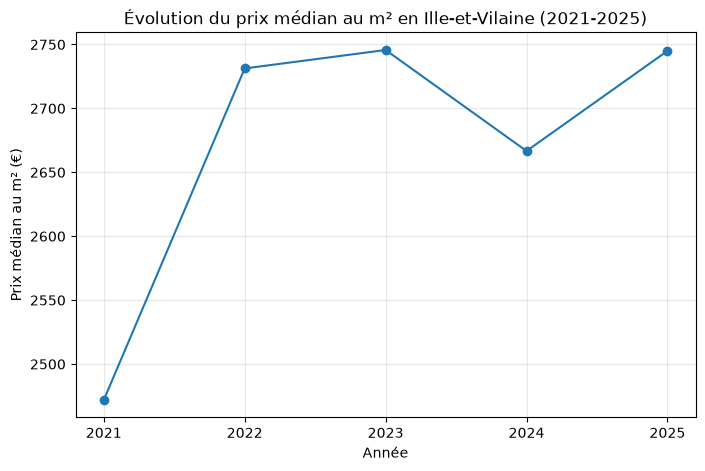

In [4]:
# Visualisation de l'évolution année par année
plt.figure(figsize=(8, 5))
plt.plot(prix_par_annee.index, prix_par_annee.values, marker="o")
plt.xlabel("Année")
plt.ylabel("Prix médian au m² (€)")
plt.title("Évolution du prix médian au m² en Ille-et-Vilaine (2021-2025)")
plt.xticks(prix_par_annee.index)
plt.grid(True, alpha=0.3)
plt.show()

In [5]:
# Hausse globale sur toute la période, pour un chiffre clé synthétique
prix_2021 = prix_par_annee[2021]
prix_2025 = prix_par_annee[2025]
hausse_pct = (prix_2025 - prix_2021) / prix_2021 * 100

print(f"Prix médian 2021 : {prix_2021:.0f} €/m²")
print(f"Prix médian 2025 : {prix_2025:.0f} €/m²")
print(f"Hausse sur la période : {hausse_pct:.1f} %")

Prix médian 2021 : 2472 €/m²
Prix médian 2025 : 2745 €/m²
Hausse sur la période : 11.0 %


**Conclusion :** le prix médian au m² en Ille-et-Vilaine est passé de 2 472 €/m² en 2021 à 2 745 €/m² en 2025, soit une hausse de 11 % sur la période. Cette progression n'est cependant pas régulière : elle se concentre presque entièrement sur 2021-2022 (+10,5 % en un an), suivie d'un plateau ondulant entre 2 665 et 2 745 €/m² de 2022 à 2025, sans nouvelle tendance haussière marquée depuis.

## 3. Classement des communes et position de Rennes

Question business : quelles communes sont les plus chères, lesquelles restent abordables, et où se situe Rennes ? Avec 333 communes dans le département, un classement complet ne serait pas lisible : on retient un top 15 / flop 15, en écartant les communes trop peu représentées pour donner une médiane fiable.

In [6]:
# Nombre de communes distinctes dans le jeu de données
df["nom_commune"].nunique()

333

In [7]:
# Nombre de ventes par commune, pour repérer les communes trop peu
# représentées pour un calcul de médiane fiable
ventes_par_commune = df["nom_commune"].value_counts()

ventes_par_commune.describe()

count      333.000000
mean       229.486486
std        966.745228
min          9.000000
25%         49.000000
50%         93.000000
75%        183.000000
max      16940.000000
Name: count, dtype: float64

In [8]:
# Comparaison de plusieurs seuils de ventes minimum, pour choisir un
# seuil qui écarte les communes fragiles sans trop réduire le classement
for seuil in [10, 20, 30, 50]:
    nb_communes = (ventes_par_commune >= seuil).sum()
    print(f"Communes avec au moins {seuil} ventes : {nb_communes}")

Communes avec au moins 10 ventes : 331
Communes avec au moins 20 ventes : 318
Communes avec au moins 30 ventes : 300
Communes avec au moins 50 ventes : 247


In [9]:
# On ne garde que les communes avec au moins 30 ventes sur la période,
# puis on calcule le prix médian au m² pour chacune, trié du plus cher
# au moins cher
communes_eligibles = ventes_par_commune[ventes_par_commune >= 30].index

df_communes = df[df["nom_commune"].isin(communes_eligibles)]

prix_par_commune = df_communes.groupby("nom_commune")["prix_m2"].median().sort_values(ascending=False)

print(prix_par_commune.shape)

(300,)


In [10]:
# Extraction du top 15 (communes les plus chères) et du flop 15
# (communes les plus abordables, réordonné du moins cher au plus cher)
top15 = prix_par_commune.head(15)
flop15 = prix_par_commune.tail(15).sort_values()

print("Top 15 des communes les plus chères :")
print(top15)
print()
print("Flop 15 des communes les plus abordables :")
print(flop15)

Top 15 des communes les plus chères :
nom_commune
Dinard                     4678.362573
Saint-Briac-sur-Mer        4444.444444
Saint-Lunaire              4277.436782
Saint-Malo                 4251.735882
Saint-Suliac               3797.294643
Cesson-Sévigné             3739.111407
Rennes                     3734.109884
Saint-Grégoire             3658.536585
Cancale                    3636.363636
Saint-Jouan-des-Guérets    3547.759563
Saint-Coulomb              3506.493506
Betton                     3381.818182
Le Minihic-sur-Rance       3292.682927
La Richardais              3287.671233
Pacé                       3266.666667
Name: prix_m2, dtype: float64

Flop 15 des communes les plus abordables :
nom_commune
Rimou                             935.761589
Poilley                           953.392330
Princé                           1000.000000
Chelun                           1067.816092
Saint-Georges-de-Reintembault    1071.428571
Le Ferré                         1150.000000
Saint-Gan

In [11]:
# Position de Rennes dans le classement complet des communes éligibles
rang_rennes = prix_par_commune.index.get_loc("Rennes") + 1

print(f"Rennes se classe {rang_rennes}e sur {len(prix_par_commune)} communes, à {prix_par_commune['Rennes']:.0f} €/m²")

Rennes se classe 7e sur 300 communes, à 3734 €/m²


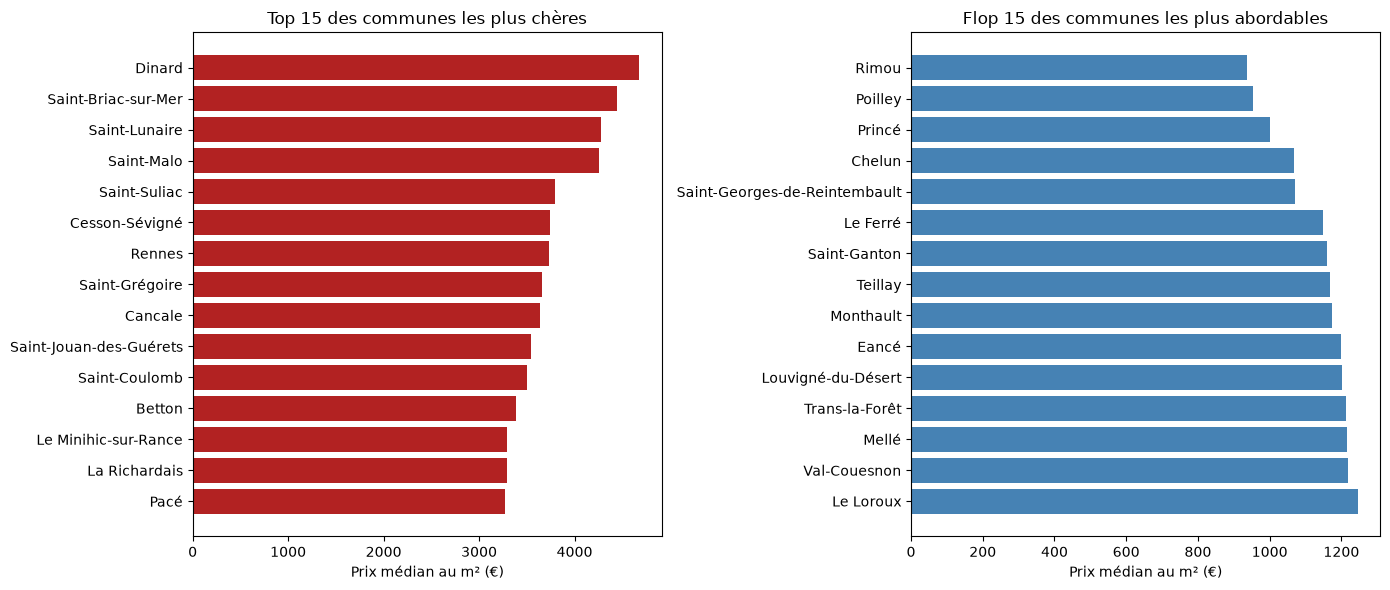

In [12]:
# Visualisation du top 15 et du flop 15 côte à côte, dans le même sens
# de lecture (commune la plus extrême en haut des deux graphiques)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].barh(top15.index[::-1], top15.values[::-1], color="firebrick")
axes[0].set_xlabel("Prix médian au m² (€)")
axes[0].set_title("Top 15 des communes les plus chères")

axes[1].barh(flop15.index[::-1], flop15.values[::-1], color="steelblue")
axes[1].set_xlabel("Prix médian au m² (€)")
axes[1].set_title("Flop 15 des communes les plus abordables")

plt.tight_layout()
plt.savefig("../screenshots/02_top_flop_communes.png", dpi=150, bbox_inches="tight")
plt.show()

**Conclusion :** le prix médian au m² varie fortement selon la commune, de 936 €/m² à Rimou jusqu'à 4 678 €/m² à Dinard, soit un rapport de 1 à 5 au sein du même département. Le marché le plus cher se concentre sur deux zones distinctes : la Côte d'Émeraude (Dinard, Saint-Briac-sur-Mer, Saint-Lunaire, Saint-Malo, Cancale...) et la première couronne rennaise (Cesson-Sévigné, Rennes, Saint-Grégoire, Betton, Pacé...). Rennes se classe 7e sur 300 communes analysées, à 3 734 €/m², confirmant son statut de marché tendu. Les communes les plus abordables se situent à l'opposé, aux marges est et nord-est du département, loin des pôles d'attractivité économique et résidentielle.

## 4. Maisons vs appartements

Question business : quel écart de prix existe entre maisons et appartements, et lequel des deux marchés est le plus dynamique en volume de ventes ? Deux volets à traiter séparément : l'écart de prix, puis le dynamisme (volume de ventes et son évolution dans le temps).

In [13]:
# Prix médian au m² pour chaque type de bien
prix_par_type = df.groupby("type_local")["prix_m2"].median()

print(prix_par_type)

type_local
Appartement    3241.463415
Maison         2284.942254
Name: prix_m2, dtype: float64


In [14]:
# Écart de prix entre les deux types, en pourcentage
prix_appartement = prix_par_type["Appartement"]
prix_maison = prix_par_type["Maison"]
ecart_pct = (prix_appartement - prix_maison) / prix_maison * 100

print(f"Prix médian appartement : {prix_appartement:.0f} €/m²")
print(f"Prix médian maison : {prix_maison:.0f} €/m²")
print(f"Écart : {ecart_pct:.1f} %")

Prix médian appartement : 3241 €/m²
Prix médian maison : 2285 €/m²
Écart : 41.9 %


In [15]:
# Volume de ventes total par type de bien, et part de marché de chacun
volume_par_type = df["type_local"].value_counts()

print(volume_par_type)

part_appartement = volume_par_type["Appartement"] / len(df) * 100
part_maison = volume_par_type["Maison"] / len(df) * 100

print(f"\nPart des appartements : {part_appartement:.1f} %")
print(f"Part des maisons : {part_maison:.1f} %")

type_local
Maison         45222
Appartement    31197
Name: count, dtype: int64

Part des appartements : 40.8 %
Part des maisons : 59.2 %


In [16]:
# Volume de ventes par année et par type, pour voir si la répartition
# évolue dans le temps
evolution_type = df.groupby(["annee", "type_local"]).size().unstack()

print(evolution_type)

type_local  Appartement  Maison
annee                          
2021               7371   11140
2022               7049   10069
2023               5642    8155
2024               5143    7460
2025               5992    8398


In [17]:
# Même tableau converti en pourcentage, pour comparer la répartition
# d'une année sur l'autre plutôt que les volumes bruts
evolution_pct = evolution_type.div(evolution_type.sum(axis=1), axis=0) * 100

print(evolution_pct.round(1))

type_local  Appartement  Maison
annee                          
2021               39.8    60.2
2022               41.2    58.8
2023               40.9    59.1
2024               40.8    59.2
2025               41.6    58.4


In [18]:
# Volume total de ventes (les deux types confondus) par année, pour
# mesurer l'évolution du marché dans son ensemble
volume_total_par_annee = evolution_type.sum(axis=1)

print(volume_total_par_annee)

baisse_pct = (volume_total_par_annee[2024] - volume_total_par_annee[2021]) / volume_total_par_annee[2021] * 100
print(f"\nÉvolution du volume total 2021 → 2024 : {baisse_pct:.1f} %")

annee
2021    18511
2022    17118
2023    13797
2024    12603
2025    14390
dtype: int64

Évolution du volume total 2021 → 2024 : -31.9 %


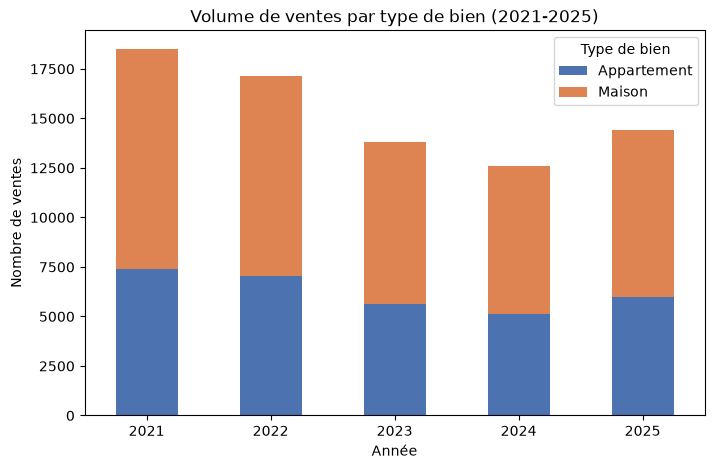

In [19]:
# Visualisation du volume de ventes par type et par année, empilé pour
# montrer à la fois le total et la répartition interne
evolution_type.plot(kind="bar", stacked=True, figsize=(8, 5), color=["#4C72B0", "#DD8452"])
plt.xlabel("Année")
plt.ylabel("Nombre de ventes")
plt.title("Volume de ventes par type de bien (2021-2025)")
plt.legend(title="Type de bien")
plt.xticks(rotation=0)
plt.show()

**Conclusion :** au m², un appartement se vend en moyenne 41,9 % plus cher qu'une maison (3 241 €/m² contre 2 285 €/m²), un écart cohérent avec la concentration des appartements en zone urbaine dense où le foncier est plus rare. En volume, les maisons dominent nettement le marché (59 % des ventes contre 41 % pour les appartements), une répartition qui reste remarquablement stable sur les cinq années étudiées (entre 39,8 % et 41,6 % d'appartements selon les années), sans qu'un des deux marchés ne gagne de terrain sur l'autre. Le vrai mouvement du marché se lit ailleurs : le volume total de ventes a chuté de 31,9 % entre 2021 et son point bas en 2024, avant un rebond partiel en 2025 qui reste 22,3 % en dessous du niveau de 2021. Ce ralentissement touche les deux types de biens dans les mêmes proportions, ce n'est donc pas un marché plus dynamique que l'autre, mais un marché globalement moins actif depuis 2021.

## 5. Effet de la surface sur le prix au m²

Question business : la surface d'un bien influence-t-elle son prix au m² ? Trois angles complémentaires : un nuage de points pour une première impression visuelle, un coefficient de corrélation pour un chiffre précis, puis une comparaison par tranches de surface pour des chiffres concrets et exploitables.

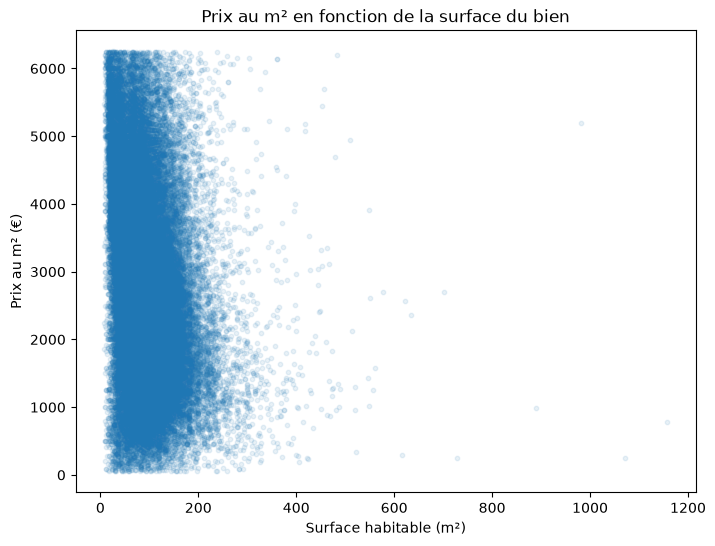

In [20]:
# Nuage de points : chaque point est une vente, surface en abscisse,
# prix au m² en ordonnée. Transparence élevée (alpha) indispensable vu
# le nombre de points, pour distinguer les zones denses
plt.figure(figsize=(8, 6))
plt.scatter(df["surface_reelle_bati"], df["prix_m2"], alpha=0.1, s=10)
plt.xlabel("Surface habitable (m²)")
plt.ylabel("Prix au m² (€)")
plt.title("Prix au m² en fonction de la surface du bien")
plt.show()

In [21]:
# Coefficient de corrélation entre surface et prix au m²
correlation = df["surface_reelle_bati"].corr(df["prix_m2"])

print(f"Coefficient de corrélation : {correlation:.3f}")

Coefficient de corrélation : -0.282


In [22]:
# Découpage en tranches de surface, puis prix médian au m² pour
# chaque tranche
bins = [0, 50, 100, 150, 1200]
labels = ["Moins de 50 m²", "50-100 m²", "100-150 m²", "150 m² et plus"]

df["tranche_surface"] = pd.cut(df["surface_reelle_bati"], bins=bins, labels=labels)

prix_par_tranche = df.groupby("tranche_surface")["prix_m2"].median()

print(prix_par_tranche)

tranche_surface
Moins de 50 m²    3552.631579
50-100 m²         2666.666667
100-150 m²        2346.774194
150 m² et plus    2012.048193
Name: prix_m2, dtype: float64


In [23]:
# Écart chiffré entre la plus petite et la plus grande tranche
ecart_surface_pct = (prix_par_tranche["Moins de 50 m²"] - prix_par_tranche["150 m² et plus"]) / prix_par_tranche["150 m² et plus"] * 100

print(f"Écart entre les petites et grandes surfaces : {ecart_surface_pct:.1f} %")

Écart entre les petites et grandes surfaces : 76.6 %


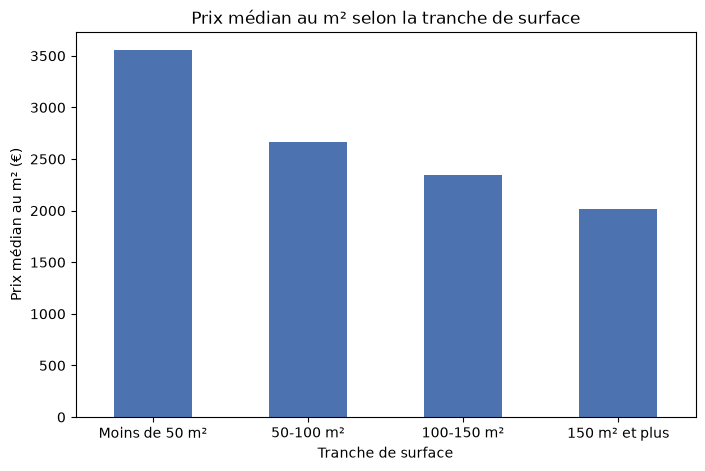

In [24]:
# Visualisation du prix médian par tranche de surface
plt.figure(figsize=(8, 5))
prix_par_tranche.plot(kind="bar", color="#4C72B0")
plt.xlabel("Tranche de surface")
plt.ylabel("Prix médian au m² (€)")
plt.title("Prix médian au m² selon la tranche de surface")
plt.xticks(rotation=0)
plt.show()

**Conclusion :** oui, la surface d'un bien influence son prix au m², et dans le sens inverse de l'intuition naïve : plus un bien est grand, moins son prix au m² est élevé. Le coefficient de corrélation (-0,282) confirme une relation négative, mais d'intensité modérée : la surface n'est qu'un facteur parmi d'autres, la localisation jouant probablement un rôle plus déterminant. La comparaison par tranches est plus parlante : le prix médian passe de 3 553 €/m² pour les biens de moins de 50 m² à 2 012 €/m² pour ceux de 150 m² et plus, une baisse régulière et sans exception à chaque tranche, soit un écart de 76,6 % entre les deux extrêmes. Pour l'agence, ce résultat traduit un principe économique classique : les petites surfaces (studios, T2) restent recherchées et se paient proportionnellement plus cher au m², tandis que les grandes surfaces bénéficient d'un effet de volume qui fait baisser leur prix unitaire.

## 6. Saisonnalité des ventes

Question business : les ventes se concentrent-elles sur certaines périodes de l'année entre 2021 et 2025 ? Il faut d'abord extraire le mois de chaque vente à partir de `date_mutation`, une colonne stockée en texte qu'il faut convertir en vraie date au préalable.

In [25]:
# Type actuel de la colonne date_mutation, avant toute conversion
df["date_mutation"].dtype

<StringDtype(storage='python', na_value=nan)>

In [26]:
# Conversion en vraie date, indispensable pour pouvoir en extraire le
# mois avec .dt.month ensuite
df["date_mutation"] = pd.to_datetime(df["date_mutation"])

df["date_mutation"].dtype

dtype('<M8[us]')

In [27]:
# Extraction du mois de chaque vente, puis comptage des ventes par
# mois (triées dans l'ordre chronologique, pas par fréquence)
df["mois"] = df["date_mutation"].dt.month

ventes_par_mois = df["mois"].value_counts().sort_index()

print(ventes_par_mois)

mois
1     5549
2     5194
3     6436
4     5602
5     5966
6     7311
7     8747
8     6125
9     7108
10    6284
11    5151
12    6946
Name: count, dtype: int64


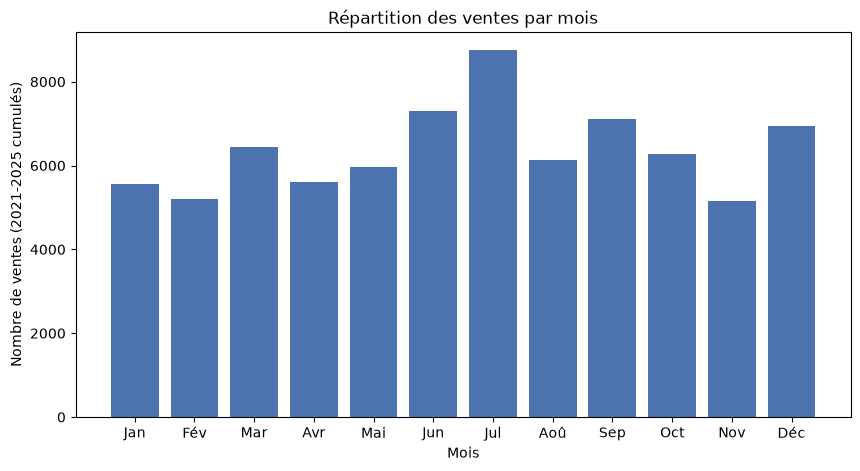

In [28]:
# Visualisation de la répartition des ventes par mois
noms_mois = ["Jan", "Fév", "Mar", "Avr", "Mai", "Jun", "Jul", "Aoû", "Sep", "Oct", "Nov", "Déc"]

plt.figure(figsize=(10, 5))
plt.bar(noms_mois, ventes_par_mois.values, color="#4C72B0")
plt.xlabel("Mois")
plt.ylabel("Nombre de ventes (2021-2025 cumulés)")
plt.title("Répartition des ventes par mois")
plt.show()

In [29]:
# Écart entre le mois le plus actif et le plus calme
ventes_juillet = ventes_par_mois[7]
ventes_fevrier = ventes_par_mois[2]
ecart_saisonnier_pct = (ventes_juillet - ventes_fevrier) / ventes_fevrier * 100

print(f"Ventes en juillet : {ventes_juillet}")
print(f"Ventes en février : {ventes_fevrier}")
print(f"Écart : {ecart_saisonnier_pct:.1f} %")

Ventes en juillet : 8747
Ventes en février : 5194
Écart : 68.4 %


**Conclusion :** oui, une saisonnalité nette existe sur le marché immobilier d'Ille-et-Vilaine. Juillet est le mois le plus actif (8 747 ventes cumulées sur 2021-2025), suivi de juin et septembre, tandis que février est le mois le plus calme (5 194 ventes), suivi de près par novembre et janvier, soit un écart de 68,4 % entre les deux extrêmes. Ce profil est cohérent avec la logique familiale classique du marché français : les acheteurs cherchent à finaliser leur déménagement avant la rentrée scolaire de septembre, ce qui concentre les signatures sur les mois d'été. Pour l'agence, ce constat a une valeur opérationnelle directe : l'été est la période à la fois la plus active commercialement et la plus concurrentielle, tandis que l'hiver (particulièrement février) offre plus de disponibilité pour un accompagnement personnalisé des clients.